In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# Import necessary libraries
import shutil
import random
import tensorflow as tf
from skimage import io
from PIL import Image
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, GlobalAveragePooling2D, concatenate
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set the data directory
dataset_dir = '/content/drive/MyDrive/dataset/Melanoma-aug-dataset'

# Define constants
batch_size = 32
image_size = (224, 224)

# Data generator with normalization and validation split
datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.3
)

# Train and validation generators
train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 653 images belonging to 3 classes.
Found 279 images belonging to 3 classes.


In [32]:
# Load pre-trained InceptionV3 model without top layers
base_model_InceptionV3 = InceptionV3(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Add custom top layers to InceptionV3
x = base_model_InceptionV3.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions_InceptionV3 = Dense(2, activation='softmax')(x)  # Change activation to 'softmax'

# Create the InceptionV3 model
model_InceptionV3 = Model(inputs=base_model_InceptionV3.input, outputs=predictions_InceptionV3)

# Freeze layers in InceptionV3 base model
for layer in base_model_InceptionV3.layers:
    layer.trainable = False

# Load pre-trained ResNet50 model without top layers
base_model_ResNet50 = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Add custom top layers to ResNet50
y = base_model_ResNet50.output
y = GlobalAveragePooling2D()(y)
y = Dense(512, activation='relu')(y)
y = Dropout(0.5)(y)
predictions_ResNet50 = Dense(2, activation='softmax')(y)  # Change activation to 'softmax'

# Create the ResNet50 model
model_ResNet50 = Model(inputs=base_model_ResNet50.input, outputs=predictions_ResNet50)

# Freeze layers in ResNet50 base model
for layer in base_model_ResNet50.layers:
    layer.trainable = False

# Combine the models
combined_model_input = Input(shape=(224, 224, 3))
output_InceptionV3 = model_InceptionV3(combined_model_input)
output_ResNet50 = model_ResNet50(combined_model_input)



# Concatenate outputs
merged = concatenate([output_InceptionV3, output_ResNet50])

# Add more dense layers if needed
merged = Dense(512, activation='relu')(merged)
merged = Dropout(0.5)(merged)
merged = Dense(1, activation='sigmoid')(merged)  # Change units to 1 and activation to 'sigmoid'

# Create the final combined model
combined_model = Model(inputs=combined_model_input, outputs=merged)

# Initial Optimizer
Optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001)

# Compile the model with 'binary_crossentropy' loss
combined_model.compile(optimizer=Optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Convert class indices to binary labels
train_labels_binary = train_generator.classes
validation_labels_binary = validation_generator.classes

# Train the model
history = combined_model.fit(train_generator, epochs= 50, validation_data=validation_generator)


Epoch 1/50
24/24 [==============================] - 18s 335ms/step - loss: 0.6487 - accuracy: 0.6555 - val_loss: 0.6387 - val_accuracy: 0.6667
Epoch 2/50
24/24 [==============================] - 6s 238ms/step - loss: 0.6382 - accuracy: 0.6667 - val_loss: 0.6367 - val_accuracy: 0.6667
Epoch 3/50
24/24 [==============================] - 5s 217ms/step - loss: 0.6375 - accuracy: 0.6667 - val_loss: 0.6365 - val_accuracy: 0.6667
Epoch 4/50
24/24 [==============================] - 5s 216ms/step - loss: 0.6374 - accuracy: 0.6667 - val_loss: 0.6365 - val_accuracy: 0.6667
Epoch 5/50
24/24 [==============================] - 6s 247ms/step - loss: 0.6374 - accuracy: 0.6667 - val_loss: 0.6365 - val_accuracy: 0.6667
Epoch 6/50
24/24 [==============================] - 7s 299ms/step - loss: 0.6373 - accuracy: 0.6667 - val_loss: 0.6365 - val_accuracy: 0.6667
Epoch 7/50
24/24 [==============================] - 5s 219ms/step - loss: 0.6373 - accuracy: 0.6667 - val_loss: 0.6365 - val_accuracy: 0.6667
Epoch

In [35]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_vgg16 = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_vgg16.layers:
    layer.trainable = False


# Build custom classification head
m1_vgg16 = Sequential()
m1_vgg16.add(model_vgg16)
m1_vgg16.add(Flatten())
m1_vgg16.add(Dense(256, activation='relu'))
m1_vgg16.add(Dropout(0.5))
m1_vgg16.add(Dense(1, activation='sigmoid'))

# Compile the model
optimizer = Adam(learning_rate=0.001)


m1_vgg16.compile(loss='binary_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history = m1_vgg16.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs= 30,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/30
21/21 [==============================] - 15s 662ms/step - loss: 1.7863 - accuracy: 0.5508 - val_loss: 1.1440 - val_accuracy: 0.6667
Epoch 2/30
21/21 [==============================] - 5s 233ms/step - loss: 0.7757 - accuracy: 0.6059 - val_loss: 0.6535 - val_accuracy: 0.6667
Epoch 3/30
21/21 [==============================] - 7s 317ms/step - loss: 0.6497 - accuracy: 0.6667 - val_loss: 0.6406 - val_accuracy: 0.6667
Epoch 4/30
21/21 [==============================] - 5s 233ms/step - loss: 0.6460 - accuracy: 0.6667 - val_loss: 0.6385 - val_accuracy: 0.6667
Epoch 5/30
21/21 [==============================] - 5s 232ms/step - loss: 0.6448 - accuracy: 0.6667 - val_loss: 0.6376 - val_accuracy: 0.6667
Epoch 6/30
21/21 [==============================] - 6s 275ms/step - loss: 0.6445 - accuracy: 0.6667 - val_loss: 0.6378 - val_accuracy: 0.6667
Epoch 7/30
21/21 [==============================] - 5s 229ms/step - loss: 0.6447 - accuracy: 0.6667 - val_loss: 0.6381 - val_accuracy: 0.6667
Epoch

In [37]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_vgg16 = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_vgg16.layers:
    layer.trainable = False


# Build custom classification head
m1_vgg16 = Sequential()
m1_vgg16.add(model_vgg16)
m1_vgg16.add(Flatten())
m1_vgg16.add(Dense(1024, activation='relu'))
m1_vgg16.add(Dropout(0.5))
m1_vgg16.add(Dense(512, activation='relu'))
m1_vgg16.add(Dropout(0.5))
m1_vgg16.add(Dense(256, activation='relu'))
m1_vgg16.add(Dropout(0.5))
m1_vgg16.add(Dense(1, activation='sigmoid'))

# Compile the model
optimizer = Adam(learning_rate=0.001)


m1_vgg16.compile(loss='binary_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history = m1_vgg16.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs= 30,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/30
21/21 [==============================] - 8s 268ms/step - loss: 1.5757 - accuracy: 0.5595 - val_loss: 0.6397 - val_accuracy: 0.6667
Epoch 2/30
21/21 [==============================] - 5s 230ms/step - loss: 0.8570 - accuracy: 0.5743 - val_loss: 0.6638 - val_accuracy: 0.6667
Epoch 3/30
21/21 [==============================] - 6s 275ms/step - loss: 0.6729 - accuracy: 0.6243 - val_loss: 0.6524 - val_accuracy: 0.6667
Epoch 4/30
21/21 [==============================] - 5s 235ms/step - loss: 0.6501 - accuracy: 0.6616 - val_loss: 0.6534 - val_accuracy: 0.6667
Epoch 5/30
21/21 [==============================] - 5s 244ms/step - loss: 0.6461 - accuracy: 0.6662 - val_loss: 0.6523 - val_accuracy: 0.6667
Epoch 6/30
21/21 [==============================] - 6s 278ms/step - loss: 0.6443 - accuracy: 0.6667 - val_loss: 0.6524 - val_accuracy: 0.6667
Epoch 7/30
21/21 [==============================] - 5s 241ms/step - loss: 0.6446 - accuracy: 0.6667 - val_loss: 0.6517 - val_accuracy: 0.6667
Epoch 

# K-Fold Cross Validation

In [38]:
import numpy as np
import pandas as pd
import os
from tqdm.notebook import tqdm
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler, TensorDataset, random_split, SubsetRandomSampler, ConcatDataset

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold

# Load Dataset

In [49]:
transform = transforms.Compose([transforms.Resize((227, 227)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

batch_size = 64

train_set = torchvision.datasets.ImageFolder('/content/drive/MyDrive/dataset/melanoma-new-dataset/train_set',
                                            transform=transform)

test_set = torchvision.datasets.ImageFolder('/content/drive/MyDrive/dataset/melanoma-new-dataset/test_set',
                                            transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

classes = train_set.classes

classes




['melanoma', 'notmelanoma']

# Instantiate CNN
Replicating AlexNet for its performance

In [50]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [52]:
class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=2),
                                      nn.ReLU(inplace=True),
                                      nn.MaxPool2d(kernel_size=3, stride=2),
                                      nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, padding=2),
                                      nn.ReLU(inplace=True),
                                      nn.MaxPool2d(kernel_size=3, stride=2),
                                      nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
                                      nn.ReLU(inplace=True),
                                      nn.MaxPool2d(kernel_size=3, stride=2),                                      nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                      nn.ReLU(inplace=True),
                                      nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1),
                                      nn.ReLU(inplace=True),
                                      nn.MaxPool2d(kernel_size=3, stride=2),
                                      nn.AdaptiveAvgPool2d((6, 6))
                                     )


        self.classifier = nn.Sequential(nn.Linear(256 * 6 * 6, 4096),
                                        nn.Dropout(p=0.5),
                                        nn.Linear(4096, 4096),
                                        nn.Dropout(p=0.5),
                                        nn.Linear(4096, 2)
                                       )


    def forward(self, x):
        x = self.features(x)

        x = x.view(-1, 6 * 6 * 256)

        x = self.classifier(x)
        return x

model = AlexNet()

model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): AdaptiveAvgPool2d(output_size=(6, 6))
  )
  (classifier): Sequential(
    (0): Linear(in_fea

# Define Loss Function

CrossEntropyLoss() includes softmax (doesn't need to be defined in CNN)

In [53]:
criterion = nn.CrossEntropyLoss()

# K-Fold Cross Validation
Split train set into train and validation sets for training before predicting on test set to catch overfitting


In [54]:
torch.manual_seed(42)

#dataset = ConcatDataset([train_set, test_set])
dataset = train_set

num_epochs = 30

k = 10

splits = KFold(n_splits = k, shuffle = True, random_state = 42)

foldperf = {}

In [55]:
def train_epoch(model, device, dataloader, loss_fn, optimizer):
    train_loss, train_correct = 0.0, 0
    model.train()
    for images, labels in dataloader:

        images,labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = loss_fn(output,labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        scores, predictions = torch.max(output.data, 1)
        train_correct += (predictions == labels).sum().item()

    return train_loss, train_correct


def valid_epoch(model, device, dataloader, loss_fn):
    valid_loss, val_correct = 0.0, 0
    model.eval()
    for images, labels in dataloader:

        images, labels = images.to(device), labels.to(device)
        output = model(images)
        loss = loss_fn(output,labels)
        valid_loss += loss.item() * images.size(0)
        scores, predictions = torch.max(output.data,1)
        val_correct += (predictions == labels).sum().item()

    return valid_loss, val_correct

# Train Model

In [56]:
for fold, (train_idx,val_idx) in enumerate(splits.split(np.arange(len(dataset)))):

    print('Fold {}'.format(fold + 1))

    train_sampler = SubsetRandomSampler(train_idx)
    test_sampler = SubsetRandomSampler(val_idx)
    train_loader = DataLoader(dataset, batch_size = batch_size, sampler = train_sampler)
    test_loader = DataLoader(dataset, batch_size = batch_size, sampler = test_sampler)

    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.001)

    history = {'train_loss': [], 'test_loss': [],'train_acc':[],'test_acc':[]}

    for epoch in tqdm(range(num_epochs)):
        train_loss, train_correct=train_epoch(model, device, train_loader, criterion, optimizer)
        test_loss, test_correct=valid_epoch(model, device, test_loader, criterion)

        train_loss = train_loss / len(train_loader.sampler)
        train_acc = train_correct / len(train_loader.sampler) * 100
        test_loss = test_loss / len(test_loader.sampler)
        test_acc = test_correct / len(test_loader.sampler) * 100

        print("Epoch:{}/{} || AVG Training Loss:{:.3f} || AVG Test Loss:{:.3f} || AVG Training Acc {:.2f} % || AVG Test Acc {:.2f} %".format(epoch + 1,
                                                                                                             num_epochs,
                                                                                                             train_loss,
                                                                                                             test_loss,
                                                                                                             train_acc,
                                                                                                             test_acc))
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    foldperf['fold{}'.format(fold+1)] = history

torch.save(model,'melanoma_CNN.pt')

Fold 1


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch:1/30 || AVG Training Loss:0.693 || AVG Test Loss:0.693 || AVG Training Acc 53.06 % || AVG Test Acc 54.67 %
Epoch:2/30 || AVG Training Loss:0.692 || AVG Test Loss:0.690 || AVG Training Acc 53.51 % || AVG Test Acc 62.67 %
Epoch:3/30 || AVG Training Loss:0.691 || AVG Test Loss:0.687 || AVG Training Acc 54.11 % || AVG Test Acc 61.33 %
Epoch:4/30 || AVG Training Loss:0.691 || AVG Test Loss:0.683 || AVG Training Acc 51.87 % || AVG Test Acc 61.33 %
Epoch:5/30 || AVG Training Loss:0.689 || AVG Test Loss:0.682 || AVG Training Acc 50.82 % || AVG Test Acc 61.33 %
Epoch:6/30 || AVG Training Loss:0.688 || AVG Test Loss:0.680 || AVG Training Acc 51.42 % || AVG Test Acc 61.33 %
Epoch:7/30 || AVG Training Loss:0.687 || AVG Test Loss:0.677 || AVG Training Acc 52.02 % || AVG Test Acc 61.33 %
Epoch:8/30 || AVG Training Loss:0.686 || AVG Test Loss:0.674 || AVG Training Acc 51.27 % || AVG Test Acc 62.67 %
Epoch:9/30 || AVG Training Loss:0.682 || AVG Test Loss:0.671 || AVG Training Acc 52.32 % || AVG 

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch:1/30 || AVG Training Loss:0.569 || AVG Test Loss:0.580 || AVG Training Acc 69.81 % || AVG Test Acc 66.67 %
Epoch:2/30 || AVG Training Loss:0.566 || AVG Test Loss:0.575 || AVG Training Acc 71.45 % || AVG Test Acc 64.00 %
Epoch:3/30 || AVG Training Loss:0.572 || AVG Test Loss:0.571 || AVG Training Acc 71.15 % || AVG Test Acc 65.33 %
Epoch:4/30 || AVG Training Loss:0.574 || AVG Test Loss:0.570 || AVG Training Acc 70.10 % || AVG Test Acc 65.33 %
Epoch:5/30 || AVG Training Loss:0.562 || AVG Test Loss:0.593 || AVG Training Acc 71.00 % || AVG Test Acc 66.67 %
Epoch:6/30 || AVG Training Loss:0.563 || AVG Test Loss:0.570 || AVG Training Acc 71.90 % || AVG Test Acc 65.33 %
Epoch:7/30 || AVG Training Loss:0.551 || AVG Test Loss:0.569 || AVG Training Acc 72.20 % || AVG Test Acc 66.67 %
Epoch:8/30 || AVG Training Loss:0.560 || AVG Test Loss:0.577 || AVG Training Acc 70.70 % || AVG Test Acc 66.67 %
Epoch:9/30 || AVG Training Loss:0.590 || AVG Test Loss:0.562 || AVG Training Acc 67.86 % || AVG 

...

Epoch:1/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:2/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:3/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:4/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:5/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:6/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:7/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:8/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:9/30 || AVG Training Loss:0.000 || AVG Test Loss:0.001 || AVG Training Acc

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch:1/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:2/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:3/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:4/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:5/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:6/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:7/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:8/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:9/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch:1/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:2/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:3/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:4/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:5/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:6/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:7/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:8/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc 100.00 % || AVG Test Acc 100.00 %
Epoch:9/30 || AVG Training Loss:0.000 || AVG Test Loss:0.000 || AVG Training Acc

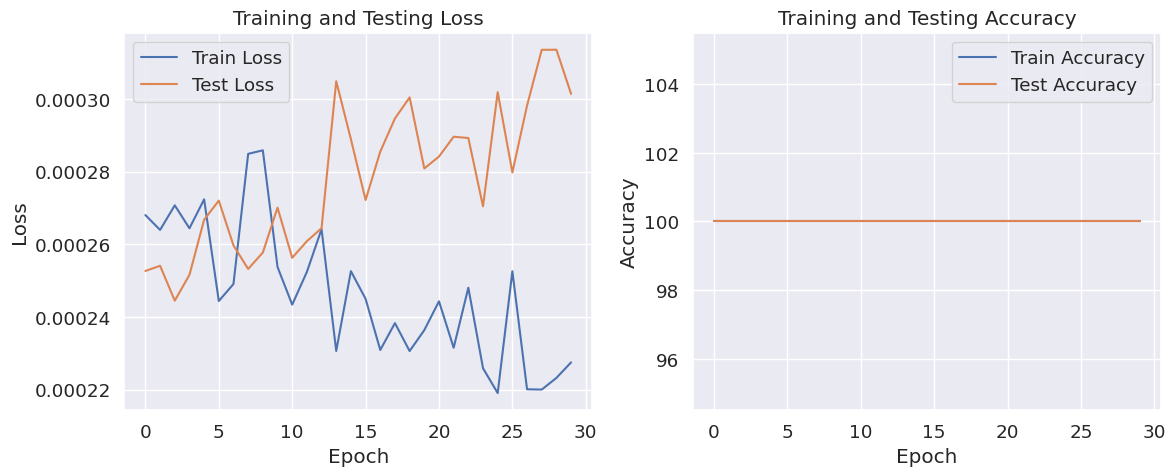

In [61]:
import matplotlib.pyplot as plt
# Plotting the training and testing loss
plt.figure(figsize=(12, 5))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Training and Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['test_acc'], label='Test Accuracy')
plt.title('Training and Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


# Predict Test Set

In [57]:
nb_classes = 2

test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    test_running_corrects = 0.0
    test_total = 0.0
    model.eval()
    for i, (test_inputs, test_labels) in enumerate(test_loader, 0):
        test_inputs, test_labels = test_inputs.cuda(), test_labels.cuda()

        test_outputs = model(test_inputs)
        _, test_outputs = torch.max(test_outputs, 1)

        test_total += test_labels.size(0)
        test_running_corrects += (test_outputs == test_labels).sum().item()

        for t, p in zip(test_labels.view(-1), test_outputs.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1


    print(f'Testing Accuracy: {(100 * test_running_corrects / test_total)}%')
print(f'Confusion Matrix:\n {confusion_matrix}')

Testing Accuracy: 80.31914893617021%
Confusion Matrix:
 tensor([[78., 19.],
        [18., 73.]])


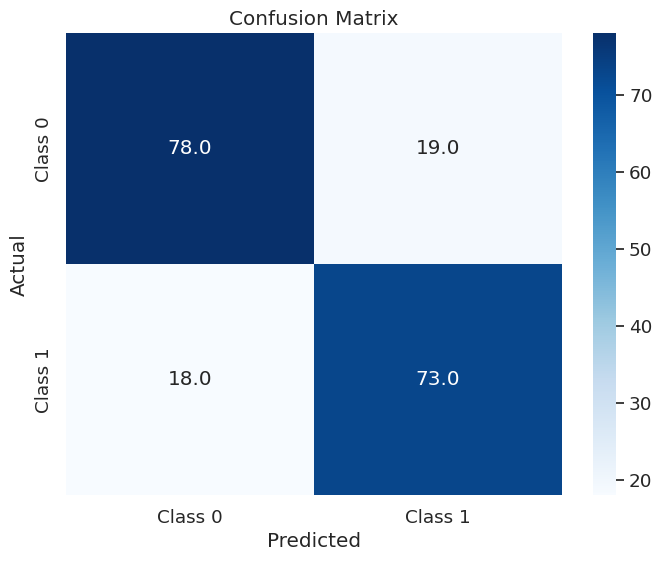

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming confusion_matrix is a torch.Tensor
confusion_matrix_np = confusion_matrix.numpy()

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Adjust the font size for better visibility

# Create a heatmap
sns.heatmap(confusion_matrix_np, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=[f'Class {i}' for i in range(nb_classes)],
            yticklabels=[f'Class {i}' for i in range(nb_classes)])

# Adding labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Show the plot
plt.show()


# F1 Score
Model accuracy tells how many correct or incorrect predictions the model made, but this isn't always the best metric

Using F1 score will factor your model's precision and recall

precision: detects type 1 errors or false positives i.e. (model predicts malignant when true value is benign)

recall: detects type 2 errors or false negatives i.e. (model predicts benign when true value is malignant)

In [58]:
precision = confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[1][0])
recall = confusion_matrix[0][0] / (confusion_matrix[0][0] + confusion_matrix[0][1])

f1_score = 2 * precision * recall / (precision + recall)
print(f'F1 Score: {f1_score: .3f}')

F1 Score:  0.808
